In [1]:
import re
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import scienceplots
from collections import Counter

/home/nlonyuk/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [4]:
import os
import sys
if '../../cp' not in sys.path:
    sys.path.append('../../cp')
from parse_planner_output import extract_tfd_plan, extract_enhsp_plan, extract_metricff_plan, extract_nfd_plan
from schedule_to_plan import extract_info, count_moves_until_2nd_service, make_new_schedule, make_new_new_schedule

In [5]:
import sys
if '../../cp' not in sys.path:
    sys.path.append('../../cp')

import json
import os
import networkx as nx
from plan import PartialPlan
from old.run_mzn import run_mzn
from old.mzn_arr_to_schedule import *
from objects import Service, Movement
from parse_planner_output import extract_enhsp_plan

In [6]:
df_tfd_base1 = pd.read_csv('../../cp/results_base1_tfd.csv')
df_tfd_base1 = df_tfd_base1.drop_duplicates(subset=['config','num_trains'])
df_tfd_base1 = df_tfd_base1.assign(planner='tfd', base='base1')

df_tfd_base2 = pd.read_csv('../../cp/results_base2_tfd.csv')
df_tfd_base2 = df_tfd_base2.drop_duplicates(subset=['config','num_trains'])
df_tfd_base2 = df_tfd_base2.assign(planner='tfd', base='base2')

df_tfd = pd.concat([df_tfd_base1, df_tfd_base2])

df_enhsp_base3 = pd.read_csv('../../cp/results_base3_enhsp.csv')
df_enhsp_base3 = df_enhsp_base3.drop_duplicates(subset=['config','num_trains'])
df_enhsp_base3 = df_enhsp_base3.assign(planner='enhsp', base='base3')

df_enhsp_base4 = pd.read_csv('../../cp/results_base4_enhsp.csv')
df_enhsp_base4 = df_enhsp_base4.drop_duplicates(subset=['config','num_trains'])
df_enhsp_base4 = df_enhsp_base4.assign(planner='enhsp', base='base4')

df_enhsp = pd.concat([df_enhsp_base3, df_enhsp_base4])

df_mff_base3 = pd.read_csv('../../cp/results_base3_metricff.csv')
df_mff_base3 = df_mff_base3.drop_duplicates(subset=['config','num_trains'])
df_mff_base3 = df_mff_base3.assign(planner='metricff', base='base3')

df_mff = df_mff_base3.copy()

df_nfd_base3 = pd.read_csv('../../cp/results_base3_nfd.csv')
df_nfd_base3 = df_nfd_base3.drop_duplicates(subset=['config','num_trains'])
df_nfd_base3 = df_nfd_base3.assign(planner='nfd', base='base3')

# df_nfd_base4 = pd.read_csv('../../cp/results_base4_nfd.csv')
# df_nfd_base4 = df_nfd_base4.drop_duplicates(subset=['config','num_trains'])
# df_nfd_base4 = df_nfd_base4.assign(planner='nfd', base='base4')

df_nfd = pd.concat([df_nfd_base3])#, df_nfd_base4])

df_base1 = df_tfd_base1.copy()
df_base2 = df_tfd_base2.copy()
df_base3 = pd.concat([df_enhsp_base3, df_mff_base3, df_nfd_base3])
df_base4 = pd.concat([df_enhsp_base4])#, df_nfd_base4])

df_temporal = pd.concat([df_base1, df_base2])
df_numeric = pd.concat([df_base3, df_base4])


In [7]:
walking_distances = {
    ("entry", "52"):3,
    ("entry", "53"):4,
    ("entry", "54"):5,
    ("entry", "55"):6,
    ("entry", "56"):7,
    ("entry", "57"):8,
    ("entry", "58"):9,
    ("entry", "59"):10,
    ("entry", "60"):8,
    ("entry", "61_service"):9,
    ("entry", "62_service"):10,
    ("entry", "63"):12,
    ("52", "53"):1,
    ("52", "54"):2,
    ("52", "55"):3,
    ("52", "56"):4,
    ("52", "57"):5,
    ("52", "58"):6,
    ("52", "59"):7,
    ("52", "60"):5,
    ("52", "61_service"):6,
    ("52", "62_service"):7,
    ("52", "63"):10,
    ("53", "54"):1,
    ("53", "55"):2,
    ("53", "56"):3,
    ("53", "57"):4,
    ("53", "58"):5,
    ("53", "59"):6,
    ("53", "60"):4,
    ("53", "61_service"):5,
    ("53", "62_service"):6,
    ("53", "63"):9,
    ("54", "55"):1,
    ("54", "56"):2,
    ("54", "57"):3,
    ("54", "58"):4,
    ("54", "59"):5,
    ("54", "60"):3,
    ("54", "61_service"):4,
    ("54", "62_service"):5,
    ("54", "63"):8,
    ("55", "56"):1,
    ("55", "57"):2,
    ("55", "58"):3,
    ("55", "59"):4,
    ("55", "60"):4,
    ("55", "61_service"):3,
    ("55", "62_service"):4,
    ("55", "63"):7,
    ("56", "57"):1,
    ("56", "58"):2,
    ("56", "59"):3,
    ("56", "60"):5,
    ("56", "61_service"):4,
    ("56", "62_service"):3,
    ("56", "63"):6,
    ("57", "58"):1,
    ("57", "59"):2,
    ("57", "60"):6,
    ("57", "61_service"):5,
    ("57", "62_service"):4,
    ("57", "63"):7,
    ("58", "59"):1,
    ("58", "60"):7,
    ("58", "61_service"):6,
    ("58", "62_service"):5,
    ("58", "63"):8,
    ("59", "60"):8,
    ("59", "61_service"):7,
    ("59", "62_service"):6,
    ("59", "63"):9,
    ("60", "61_service"):1,
    ("60", "62_service"):2,
    ("60", "63"):4,
    ("61_service", "62_service"):1,
    ("61_service", "63"):3,
    ("62_service", "63"):4,
}

In [22]:
def get_service_tracks_enhsp(plans):
    all_service_tracks = []
    for plan in plans:
        pp = PartialPlan(plan)
        pp.build_constraints()
        all_service_tracks += [act.track.name for act in pp.actions if type(act) is Service]
    return all_service_tracks



In [23]:
folders = [
    '../../results/tfd/base1', 
    '../../results/tfd/base2', 
    '../../results/enhsp/base3', 
    '../../results/enhsp/base4',
    '../../results/nfd/base3',
    '../../results/metricff/base3', 
]

In [109]:
cfgs = range(1,22)

max_percentages = {
    'TFD':[],
    'ENHSP':[],
    'Metric-ff':[],
    'NFD':[],
}


for folder in folders:
    for cfg in cfgs:
        for num_t in range(3,20):

            plan_file = f'{folder}/pln_{cfg}_{num_t}t.txt'

            if not os.path.exists(plan_file):
                continue

            if 'base3' in folder and cfg in [12,13,14]:
                continue

            if 'tfd' in folder:
                all_plans = extract_tfd_plan(plan_file)
            elif 'enhsp' in folder:
                
                all_plans, _, _, _ = extract_enhsp_plan(plan_file)
            elif 'metricff' in folder:
                all_plans, _, _ = extract_metricff_plan(plan_file)
                for i in range(len(all_plans)):
                    all_plans[i] = [f'({l.split(': ')[-1][:-1].lower()})' for l in all_plans[i]]
            elif 'nfd' in folder:
                plan = extract_nfd_plan(plan_file)
                all_plans = [plan]
            else:
                continue

            if len(all_plans) < 1:
                continue

            st = get_service_tracks_enhsp(all_plans)
            if len(st) < 1:
                continue

            counter = dict(Counter(st))
            total_count = sum(counter.values())
            percentages = [int(100*v/total_count) for v in counter.values()]
            max_percentage = round(max(percentages),-1)
            if 'tfd' in folder:
                max_percentages['TFD'].append(max_percentage)
            elif 'enhsp' in folder:
                max_percentages['ENHSP'].append(max_percentage)
            elif 'metricff' in folder:
                max_percentages['Metric-ff'].append(max_percentage)
            elif 'nfd' in folder:
                max_percentages['NFD'].append(max_percentage)
            else:
                continue



<>:33: SyntaxWarning: invalid escape sequence '\%'
<>:40: SyntaxWarning: invalid escape sequence '\%'
<>:33: SyntaxWarning: invalid escape sequence '\%'
<>:40: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_81836/3767647740.py:33: SyntaxWarning: invalid escape sequence '\%'
  labell = f'{l[i]} \% of actions at most visited service track'
/tmp/ipykernel_81836/3767647740.py:40: SyntaxWarning: invalid escape sequence '\%'
  ax.set_ylabel('Amount of plans (\%)')


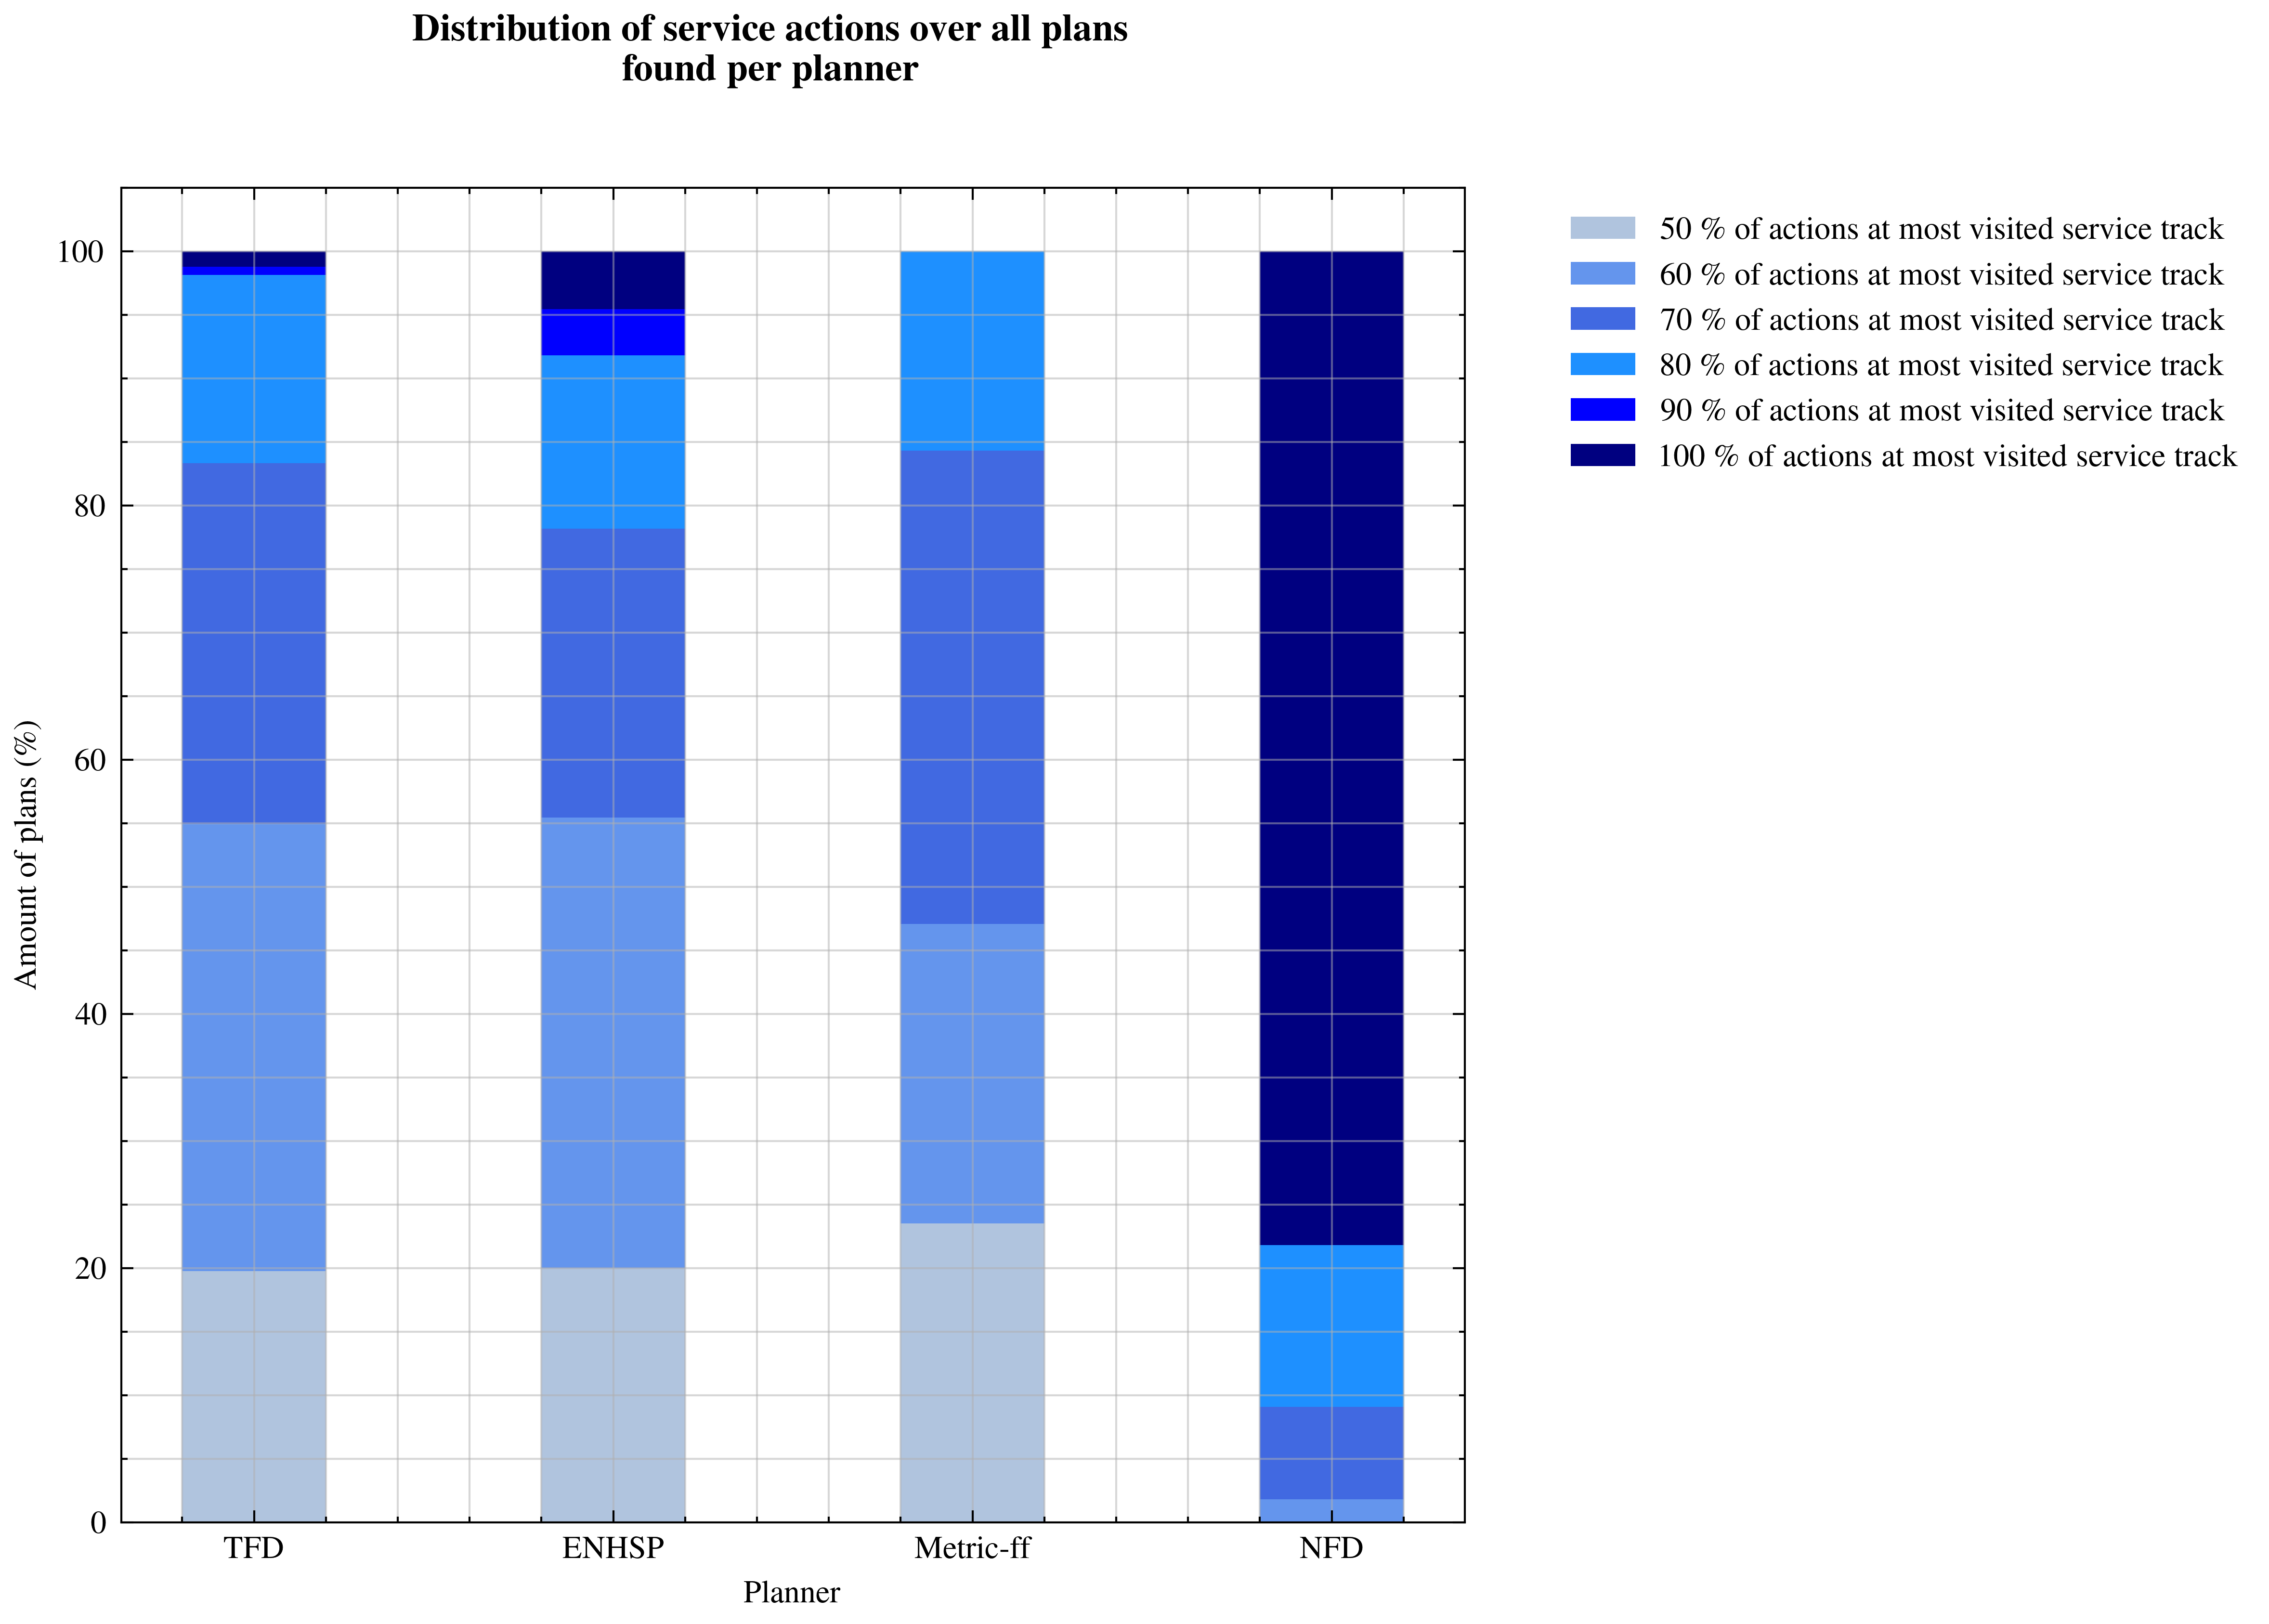

In [110]:
plt.style.use(['ieee', 'science'])

keys = list(max_percentages.keys())

fig, ax = plt.subplots(figsize=(6,6), sharey=True)
# ax = ax.flatten()

colours = {
    50:'lightsteelblue',
    60:'cornflowerblue',
    60:'cornflowerblue',
    70:'royalblue',
    80:'dodgerblue',
    90:'blue',
    100:'navy',
}

for i, k in enumerate(keys):

    percentage_counter = dict(Counter(max_percentages[k]))
    percentages = sorted(set(max_percentages[k]))
    percentage_counts = {p:100*percentage_counter[p]/len(max_percentages[k]) for p in percentages}

    bottom = 0

    for perc, count in percentage_counts.items():
        ax.bar(k, count, bottom=bottom, label=perc, width=0.4, color=colours[perc])
        bottom += count

handles,labels=[],[]
h, l = ax.get_legend_handles_labels()
for i in range(len(h)):
    labell = f'{l[i]} \% of actions at most visited service track'
    if labell not in labels:
        handles.append(h[i])
        labels.append(labell)

ax.legend(handles, labels, loc='upper right', bbox_to_anchor=(1.6, 1.0))
ax.set_xlabel('Planner')
ax.set_ylabel('Amount of plans (\%)')
ax.grid(True, alpha=0.5, which='both')
# fig.tight_layout()
fig.suptitle(r"""\textbf{Distribution of service actions over all plans}
             \textbf{found per planner}""")

fig.savefig('service_distribution.png')




In [111]:
ax.get_legend_handles_labels()

([<BarContainer object of 1 artists>,
  <BarContainer object of 1 artists>,
  <BarContainer object of 1 artists>,
  <BarContainer object of 1 artists>,
  <BarContainer object of 1 artists>,
  <BarContainer object of 1 artists>,
  <BarContainer object of 1 artists>,
  <BarContainer object of 1 artists>,
  <BarContainer object of 1 artists>,
  <BarContainer object of 1 artists>,
  <BarContainer object of 1 artists>,
  <BarContainer object of 1 artists>,
  <BarContainer object of 1 artists>,
  <BarContainer object of 1 artists>,
  <BarContainer object of 1 artists>,
  <BarContainer object of 1 artists>,
  <BarContainer object of 1 artists>,
  <BarContainer object of 1 artists>,
  <BarContainer object of 1 artists>,
  <BarContainer object of 1 artists>],
 ['50',
  '60',
  '70',
  '80',
  '90',
  '100',
  '50',
  '60',
  '70',
  '80',
  '90',
  '100',
  '50',
  '60',
  '70',
  '80',
  '60',
  '70',
  '80',
  '100'])

In [112]:
len(max_percentages['tfd'])

KeyError: 'tfd'

In [ ]:
percentage_counter

{100: 43, 70: 6, 80: 7, 50: 2, 60: 2}

NameError: name 'x_3' is not defined

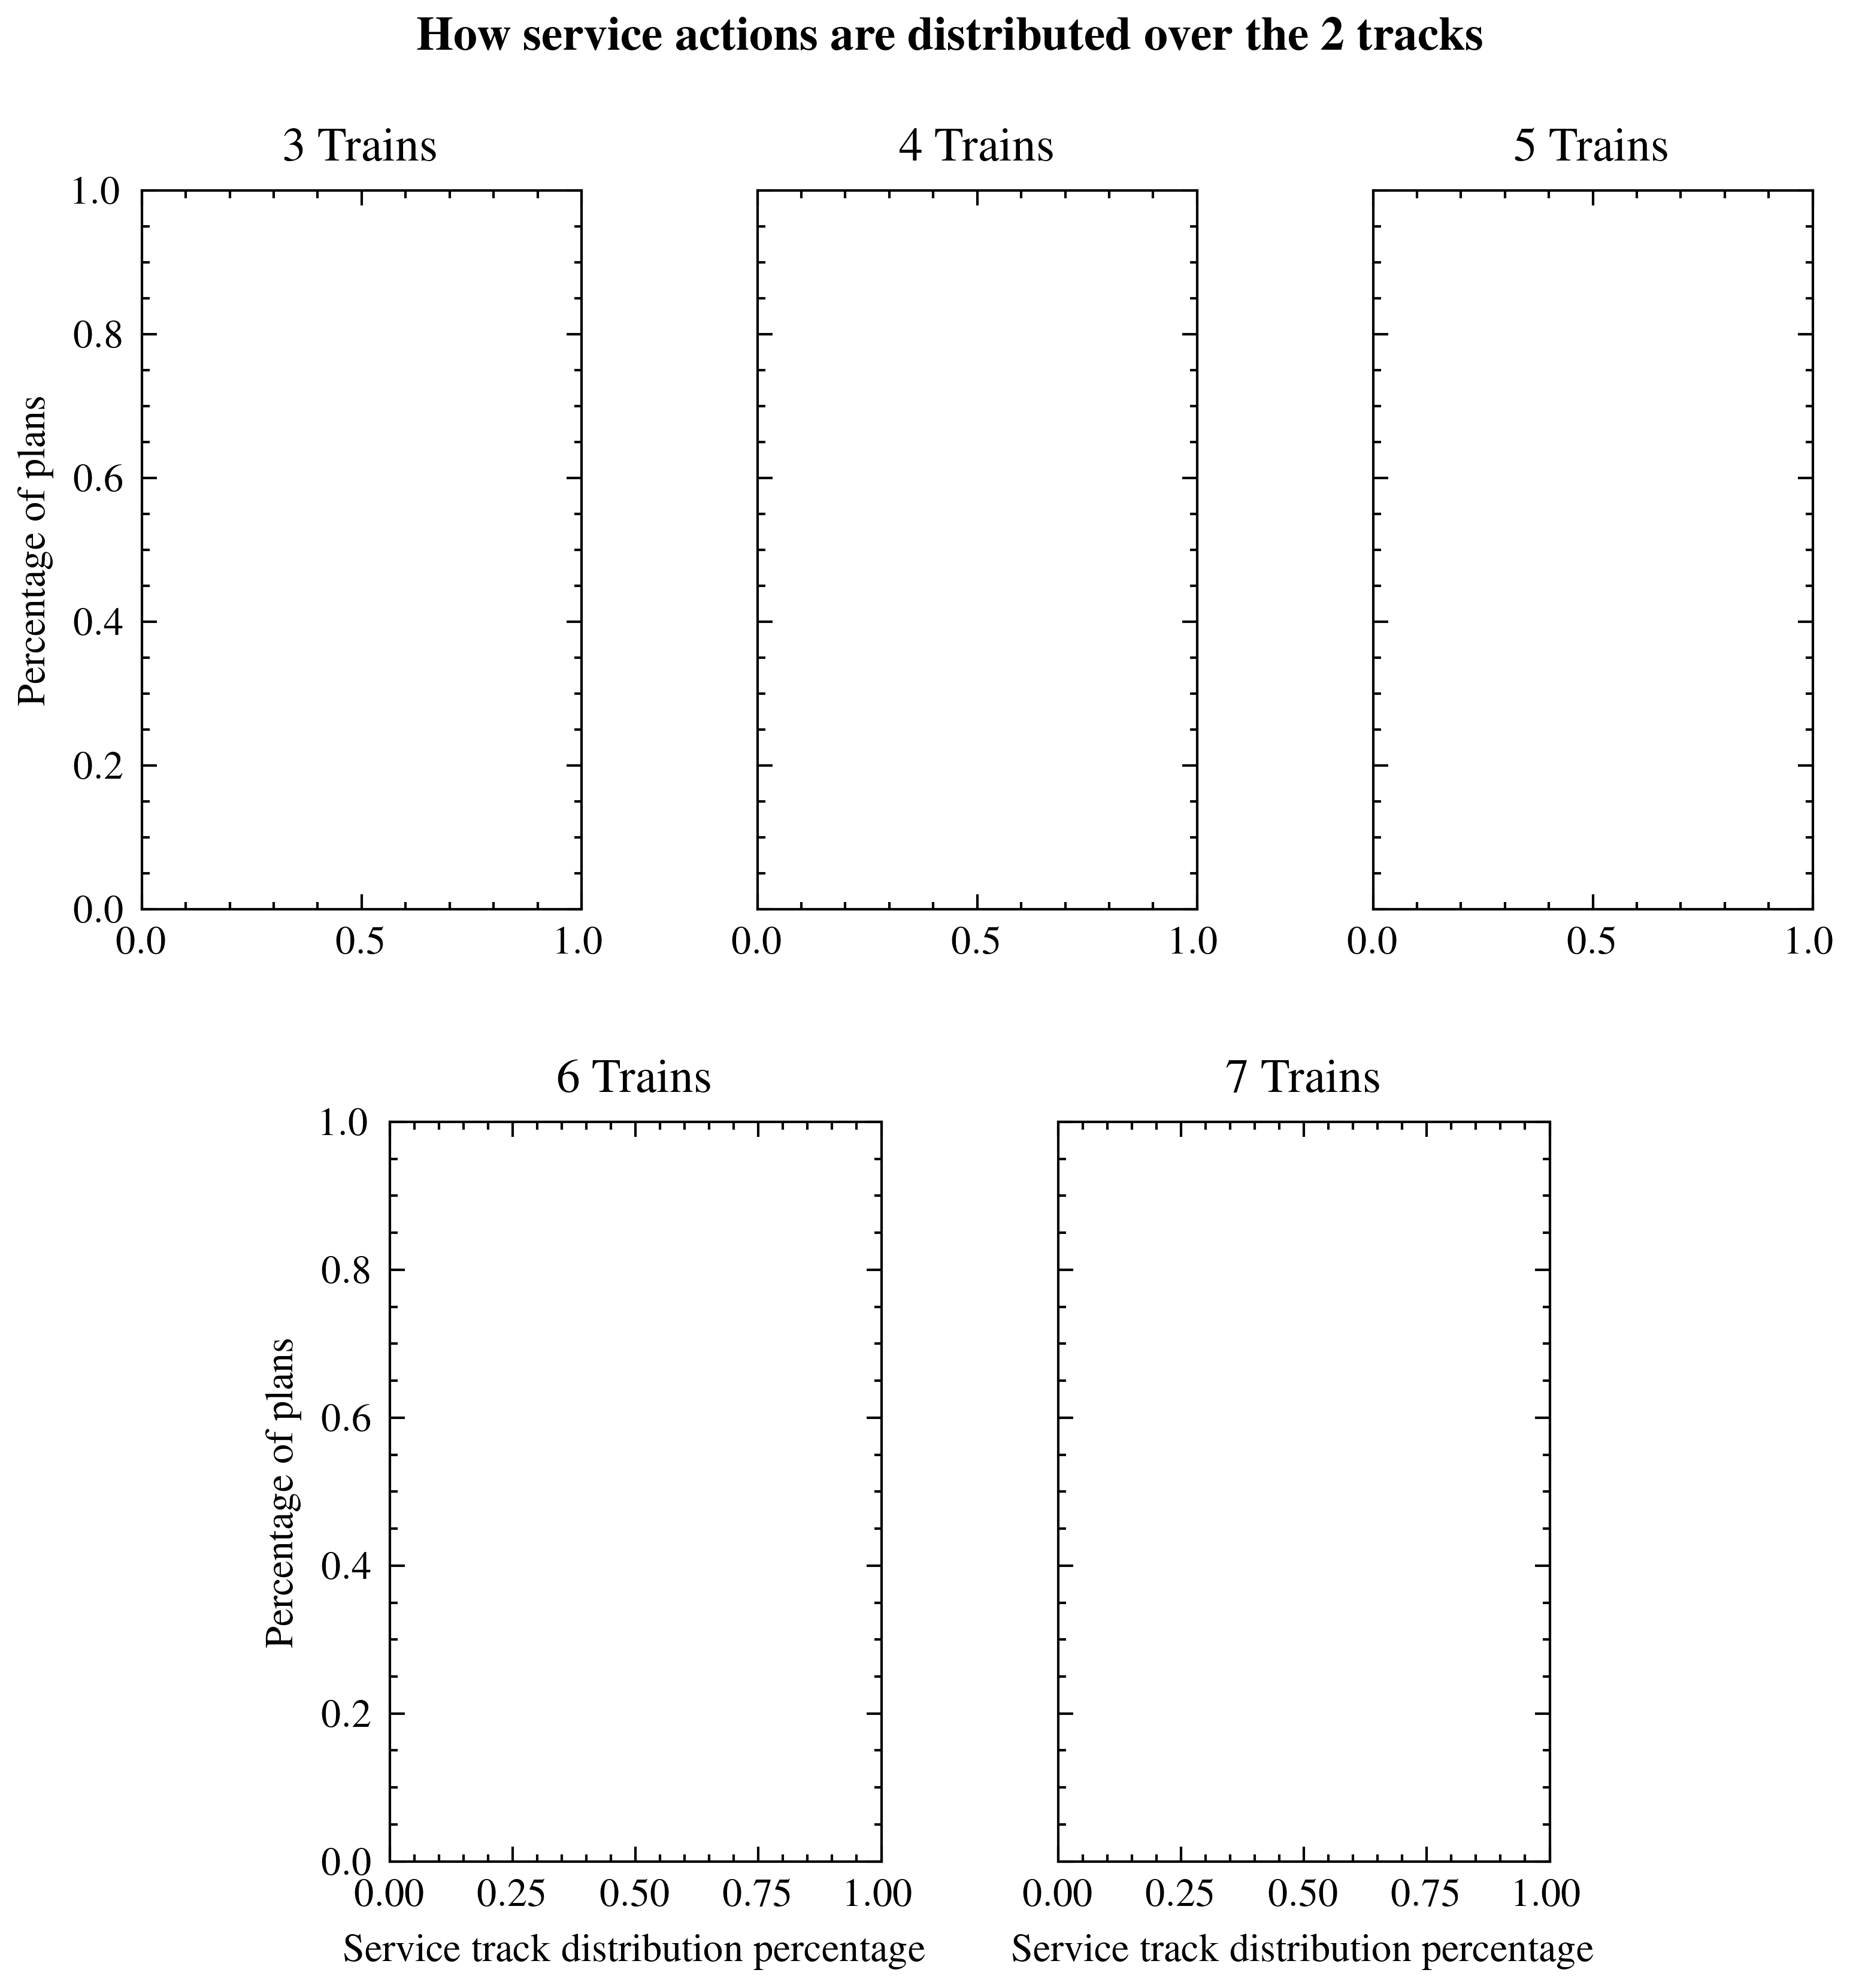

In [ ]:
plt.style.use(['ieee', 'science'])

yticks = [10*i for i in range(1,11)]


fig, ax = plt.subplots(2,3, figsize=(6,6), sharey=True)
ax = ax.flatten()
ax[5].set_visible(False)

fig.subplots_adjust(bottom=0.1, 
                    top=0.9, wspace=0.4,hspace=0.4)

ax[3].set_position([0.24,0.125,0.228,0.343])
ax[4].set_position([0.55,0.125,0.228,0.343])



fig.suptitle(r"""\textbf{How service actions are distributed over the 2 tracks}""")

ax[0].set_ylabel('Percentage of plans')
ax[3].set_ylabel('Percentage of plans')
ax[3].set_xlabel('Service track distribution percentage')
ax[4].set_xlabel('Service track distribution percentage')
ax[5].set_xlabel('Service track distribution percentage')

ax[0].set_title('3 Trains')
ax[1].set_title('4 Trains')
ax[2].set_title('5 Trains')
ax[3].set_title('6 Trains')
ax[4].set_title('7 Trains')
ax[5].set_title('8 Trains')


width = 0.3
ax[0].bar(x_3-0.5*width, temporal_values_3, width, label='temporal', color='blue')
ax[0].bar(x_3+0.5*width, numeric_values_3, width, label='numeric', color='orange')
ax[0].grid(True, alpha=0.5)
ax[0].set_xticks(x_3, keys_3)
ax[0].tick_params(axis='x', labelrotation=45)
ax[0].legend(loc='upper right')
ax[0].set_yticks(yticks)

ax[1].bar(x_4-0.5*width, temporal_values_4, width, label='temporal', color='blue')
ax[1].bar(x_4+0.5*width, numeric_values_4, width, label='numeric', color='orange')
ax[1].grid(True, alpha=0.5)
ax[1].set_xticks(x_4+width/2, keys_4)
ax[1].tick_params(axis='x', labelrotation=45)
ax[1].set_yticks(yticks)
# ax[1].legend(loc='upper right')

ax[2].bar(x_5-0.5*width, temporal_values_5, width, label='temporal', color='blue')
ax[2].bar(x_5+0.5*width, numeric_values_5, width, label='numeric', color='orange')
ax[2].grid(True, alpha=0.5)
ax[2].set_xticks(x_5, keys_5)
ax[2].tick_params(axis='x', labelrotation=45)
ax[2].set_yticks(yticks)
# ax[2].legend(loc='upper right')

ax[3].bar(x_6-0.5*width, temporal_values_6, width, label='temporal', color='blue')
ax[3].bar(x_6+0.5*width, numeric_values_6, width, label='numeric', color='orange')
ax[3].grid(True, alpha=0.5)
ax[3].set_xticks(x_6+width/2, keys_6)
ax[3].tick_params(axis='x', labelrotation=45)
ax[3].set_yticks(yticks)
# ax[3].legend(loc='upper right')

ax[4].bar(x_7-0.5*width, temporal_values_7, width, label='temporal', color='blue')
ax[4].bar(x_7+0.5*width, numeric_values_7, width, label='numeric', color='orange')
ax[4].grid(True, alpha=0.5)
ax[4].set_xticks(x_7+width/2, keys_7)
ax[4].tick_params(axis='x', labelrotation=45)
ax[4].set_yticks(yticks)
# ax[4].legend(loc='upper right')

ax[5].bar(x_8, temporal_values_8, width, label='temporal', color='blue')
# ax[5].bar(x_8+0.5*width, numeric_values_8, width, label='numeric', color='orange')
ax[5].grid(True, alpha=0.5)
ax[5].set_xticks(x_8+width/2, keys_8)
ax[5].tick_params(axis='x', labelrotation=45)
ax[5].set_yticks(yticks)
# ax[5].legend(loc='upper right')

# plt.tight_layout()

fig.savefig('service_distribution.png')

In [ ]:
temporal_ratios